In [1]:
import torch
import math
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
import numpy as np
# ===== 添加下面这两行，解决中文显示问题 =====
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False

# Yarn策略(以minimind的实现为标准)
高频完全外推，低频完全插值，中间平滑过渡

- 基频$\textcolor{red}{有问题}$：
$$ \theta_i = \text{rope\_base}^{-2i/d}\;,\;i\in \left[0,2,\cdots,d-2\right] $$
**注**：其中$i$表示token特征向量的第$i$个**特征对**。对于token特征维度为$\text{(batch\_size, seq\_len, d\_model)}$的张量，依照特定规则按照复数构造法则两两配对。为了方便表述，记$d :=\text{d\_model}$。在该项目中$d$的值是：$\text{hidden\_size}/\text{num\_attention\_heads}=768/8=96$。  
  
**基频与特征下标的关系：** 最大下标$d$，当$i: 0\to d$时，有$\theta_i: 1 \to \frac{1}{\text{rope\_base}}$。即，$i$增大$\theta_i$减小。
- 波长：
$$ \lambda_i = \frac{2\pi}{\theta_i}=2\pi \cdot \text{rope\_base}^{2i/d}$$
**为什么要定义这个波长？**：要注意，不同token相同特征位置$i$上的基频$\theta_i$是相同的。但，不同位置的具体旋转角度是不同的，例如第$m$个token（准确说是第$m$对二维特征向量切片）的旋转角度是$m\theta_i$。
- 高频：基频$\theta_i$大，波长$\lambda_i$短，$i$小。
- 低频：基频$\theta_i$小，波长$\lambda_i$长，$i$大。  
由于，不同token的相同索引$i$特征对的相对位置信息由$(m-n)\theta_i$决定。假设，预训练阶段的token长度$L_{\text{orig}}$有限，此时有
$$\max_{m,n}\{(m-n)\}\theta^{\text{high}}_i=L_{\text{orig}}\theta^{\text{high}}_i>2\pi$$
$$\max_{m,n}\{(m-n)\}\theta^{\text{low}}_i=L_{\text{orig}}\theta^{\text{low}}_i<2\pi$$
那么，在预训练阶段对于任意的$m,n$组成的相对位置信息$(m-n)\theta_i$，高频特征能够遍历整个$(0,2\pi)$空间，但是低频特征却不可以。所以，在处理长文本外推时($L>L_{\text{orig}}$)，低频特征是不够鲁棒的，会遇到预训练时没有处理过的相对位置信息。
- 外推：
- 插值：

## 维度索引函数inv_dim
$$
\text{inv\_dim(b)}=\frac{d\cdot \log \left(\frac{L_{\text{orig}}}{2\pi b}\right)}{2\cdot \log (\text{rope\_base})}\tag{1}
$$
由于Yarn的策略涉及对“高频”和“低频”的区分，而如何通过特征下标$i$区分“高/低”频是代码实现的关键。  
**注意：** 基频-波长-索引$i$ 之间存在着对应关系。所以，代码中能够通过“区分”波长来寻找对应的索引$i$，即$\lambda_i = \frac{L_{\text{orig}}}{b}$。  
  

(1)式的推导：
$$
\begin{align}
\lambda_i &= \frac{2\pi}{\theta_i}=\frac{L_{\text{orig}}}{b}\notag\\
\Rightarrow& 2\pi \cdot \text{rope\_base}^{\frac{2i}{d}}=\frac{L_{\text{orig}}}{b}\notag\\
\Rightarrow& \underbrace{\log\left(\text{rope\_base}\right)^{\frac{2i}{d}}}_{\frac{2i}{d}\log\left(\text{rope\_base}\right)}=\log\left(\frac{L_{\text{orig}}}{2\pi b}\right)\notag\\
\Rightarrow& i = \frac{d\cdot\log \left(\frac{L_{\text{orig}}}{2\pi b}\right)}{2\log \left(\text{rope\_base}\right)}\tag{2}
\end{align}
$$
由上式可知，$b$越大，$i$越小，波长短，基频大（即，大$b$对应高频）。在源代码的实现中，用于区分高/低频的参数分别是：
$$
\beta_{\text{fast}}:=32.0\;,\;\beta_{\text{slow}}:=1
$$
即，大于等于$\beta_{\text{fast}}$的输入所得到的索引$i$对应高频特征。小于等于$\beta_{\text{low}}$的输入所得到的索引$i$对应低频特征。
$$
i_{\text{low}}:=\max(\lfloor \text{inv\_dim}(\beta_{\text{fast}}) \rfloor,0)
$$
$$
i_{\text{high}}:=\min(\lceil \text{inv\_dim}(\beta_{\text{slow}}) \rceil,\frac{d}{2}-1 )
$$

```python
torch.clamp(torch.tensor,0,1)
```
该函数保证torch.tensor中的各项数值在$\left[0,1\right]$范围内。  
  
### 线性斜坡
代码：
```python
ramp = torch.clamp((torch.arange(dim // 2, device = freqs.device).float() - low) / max(high - low, 0.001), 0, 1)
```
其中$\text{low}:=i_{\text{low}}$；$\text{high}:=i_{\text{high}}$。在该项目中，这两项的值分别是8和21。
$$
\text{ramp}[j]=
\begin{cases}
0\;,\;j=0,1,\cdots,i_{\text{low}}\\
\frac{j-i_{\text{low}}}{i_{\text{high}}-i_{\text{low}}}\;,\;j = i_{\text{low}}+1,\cdots,i_{\text{high}}-1\\
1\;,\;j=i_{\text{high}},\cdots,\text{len}(\text{ramp})
\end{cases}
$$
其中$\text{len}(\text{ramp})=\frac{d}{2}$。上式也可等价的写为函数形式，记$\gamma(j):=\text{ramp}[j]$：
$$
\gamma(j)=\text{clip}\left(\frac{j-i_{\text{low}}}{i_{\text{high}}-i_{\text{low}}},0,1\right)\;,\;j=0,1,\cdots,\underbrace{\text{len}(\text{ramp})}_{=\frac{d}{2}}
$$
在代码实现中，真正用于频率修正的是下面式子中等式右边的权重：
$$
\hat{\theta}_i=\theta_i\cdot\left(1-\gamma(i)+\frac{\gamma(i)}{s}\right)\tag{2}
$$
其中，$s$就是代码中的$\text{factor}$参数（数值为16）。

- 当$j \le i_{\text{low}}$，对应高频，此时$\gamma(j)=0$。上式右边权重为1。
- 当$j \ge i_{\text{high}}$，对应低频，此时$\gamma(j)=1$。上式右边权重为$\frac{1}{s}$。
- 对于中频部分，注意到$\gamma(j)$随$j$的增大是非减的，且(2)式中的权重部分关于$\gamma(i)$的导数为：$(-1+\frac{1}{s})<0$。所以该权重关于$j$应该是非增的。（注意：这里的$j$就是token的特征索引，和前文的$i$一致。）

In [3]:
'''
沿用模型中的参数，展示中间参数的实验结果。
'''
dim = 96
beta_fast = 32.0
beta_slow = 1.0
orig_max = 2048
rope_base = 1e6
inv_dim = lambda b: (dim * math.log(orig_max / (b * 2 * math.pi))) / (2 * math.log(rope_base))
low, high = max(math.floor(inv_dim(beta_fast)), 0), min(math.ceil(inv_dim(beta_slow)), dim // 2 - 1)
ramp = torch.clamp((torch.arange(dim // 2).float() - low) / max(high - low, 0.001), 0, 1)
ramp

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0769, 0.1538, 0.2308, 0.3077, 0.3846, 0.4615, 0.5385, 0.6154, 0.6923,
        0.7692, 0.8462, 0.9231, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000])

In [15]:
factor = 16
1-ramp+ramp/factor

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        0.9279, 0.8558, 0.7837, 0.7115, 0.6394, 0.5673, 0.4952, 0.4231, 0.3510,
        0.2788, 0.2067, 0.1346, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
        0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
        0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
        0.0625, 0.0625, 0.0625])

### 原序列长度与新序列长度
在代码中分别使用：$\text{max\_position\_embeddings}$以及$\text{original\_max\_position\_embeddings}$来表示上面两个参数。数值分别为$2048$以及$32 \times 1024=32768$。

**外积**  
代码中的实现方式
```python
torch.outer(tensor1, tensor2)
```
数学上记为：
$$
\mathbf{u}=
\begin{bmatrix}
u_1\\
u_2\\
\vdots\\
u_m
\end{bmatrix}\;\;,\;\;
\mathbf{v}=
\begin{bmatrix}
v_1\\
v_2\\
\vdots\\
v_m
\end{bmatrix}
$$
$$
(\mathbf{u}\otimes \mathbf{v})_{i,j}=u_i \times v_j\;,\;(\mathbf{u}\otimes \mathbf{v})\in\mathbb{R}^{m\times n}
$$

### “新序列位置”与“修正后频率”的耦合矩阵
```python
t = torch.arange(end, device=freqs.device)
freqs = torch.outer(t, freqs).float()
```
记该矩阵为$\Phi\in\mathbb{R}^{L_{\text{new}}\times \frac{d}{2}}$，记新序列位置为$\mathbf{t}\in [0,1,\cdots, L_{\text{new}}-1]$。所以，有：
$$
\Phi_{t,i}=\mathbf{t}_t \times \hat{\theta}_i
$$
   
### precompute_freqs_cis函数的最终返回值
该函数的最终返回值就是下面计算的两个参数：
```python
freqs_cos = torch.cat([torch.cos(freqs), torch.cos(freqs)], dim=-1) * attn_factor
freqs_sin = torch.cat([torch.sin(freqs), torch.sin(freqs)], dim=-1) * attn_factor
```
其中，$\text{attn\_factor}$在代码中为$1.0$（在下面讨论的数学表示中，记为$\alpha$）；参数$\text{freqs}$就是上一节的矩阵$\Phi$。这两个参数的数学表达式可记为（$\text{Cos}\in\mathbb{R}^{L_{\text{new}}\times d}\,,\,\text{Sin}\in\mathbb{R}^{L_{\text{new}}\times d}$）：
  
$$
\text{Cos}_{t,j}=\alpha \cdot \cos \left(\Phi_{t,j\,\text{mod}\,\frac{d}{2}}\right)
$$
$$
\text{Sin}_{t,j}=\alpha \cdot \sin \left(\Phi_{t,j\,\text{mod}\,\frac{d}{2}}\right)
$$
其中，$\text{mod}$参数的功能是“取余数”。

### 代码逻辑
这里讨论“代码逻辑”的理由是：上一节的讨论只是将位置信息关联到了$\text{Cos}, \text{Sin}$矩阵。这两个矩阵在后续运算中，通过参数$\text{start\_pos}$（还有其他参数，重点分析$\text{start\_pos}$）计算得到$\text{position\_embeddings}$参数。而$\text{start\_pos}$又直接与$\text{past\_key\_values}$参数有关。所以为了搞清楚rope以及yarn的具体作用，必须理清其中的逻辑。  
  
重点关注参数：(a) $\text{position\_embeddings}$; (b) $\text{past\_key\_values}$

  
**position_embeddings & past_key_values路径**  
-> class MiniMindModel, def forward, layer(<font color="red">利用past_key_values实现KV Cache</font>)  
-> class MiniMindModel, self.layers  
-> nn.ModuleList  
-> MiniMindBlock  
-> MiniMindBlock forward函数的参数来自，MiniMindModel forward函数中遍历nn.ModuleList容器中的MiniMindBlock组件（如下面的代码块所示）  
-> Attention  
-> Attention forward中position_embeddings这个元组被自然拆解为cos, sin  
-> 成为apply_rotary_pos_emb函数参数的其中两个

```python
# class MiniMindModel
#     def forward
position_embeddings = (self.freqs_cos[start_pos:start_pos + seq_length], self.freqs_sin[start_pos:start_pos + seq_length])
        presents = []
        for layer, past_key_value in zip(self.layers, past_key_values):
            hidden_states, present = layer(
                hidden_states,
                position_embeddings,
                past_key_value=past_key_value,
                use_cache=use_cache,
                attention_mask=attention_mask
            )
            presents.append(present)
```
其中，position_embeddings就来自于precompute_freqs_cis函数的返回值。  
<br>

**完整的代码运行逻辑需要从实际调用开始**：  
class MiniMindForCausalLM <- class MiniMindModel(self.model)  
即：self.model变量是class MiniMindModel的实例化。代码中对**模型的初始化可能封装在MiniMindForCausalLM类型的变量中**。  
<br>
class MiniMindForCausalLM, def generate <- class MiniMindForCausalLM, def forward  
即：代码中对**模型的调用可能封装在generate函数中**。  


### 待做
1. config如何初始化（类）对象？例如：
```python
self.self_attn = Attention(config)
self.mlp = FeedForward(config) if not config.use_moe else MOEFeedForward(config)
```
  
2. past_key_values的作用  
pas_key_values变量名只出现在 model_minimind.py 文件 
  
3. 模型实例化是通过 MiniMindForCausalLM 类。初始化方法里实例化了 MiniMindModel。

In [8]:
a = torch.randn(2,3)
a = torch.cos(a)
b = torch.randn(2,3)
b = torch.cos(a)
a, b

(tensor([[0.5329, 0.9308, 0.5277],
         [0.6446, 0.6873, 0.9255]]),
 tensor([[0.8613, 0.5972, 0.8639],
         [0.7993, 0.7730, 0.6014]]))

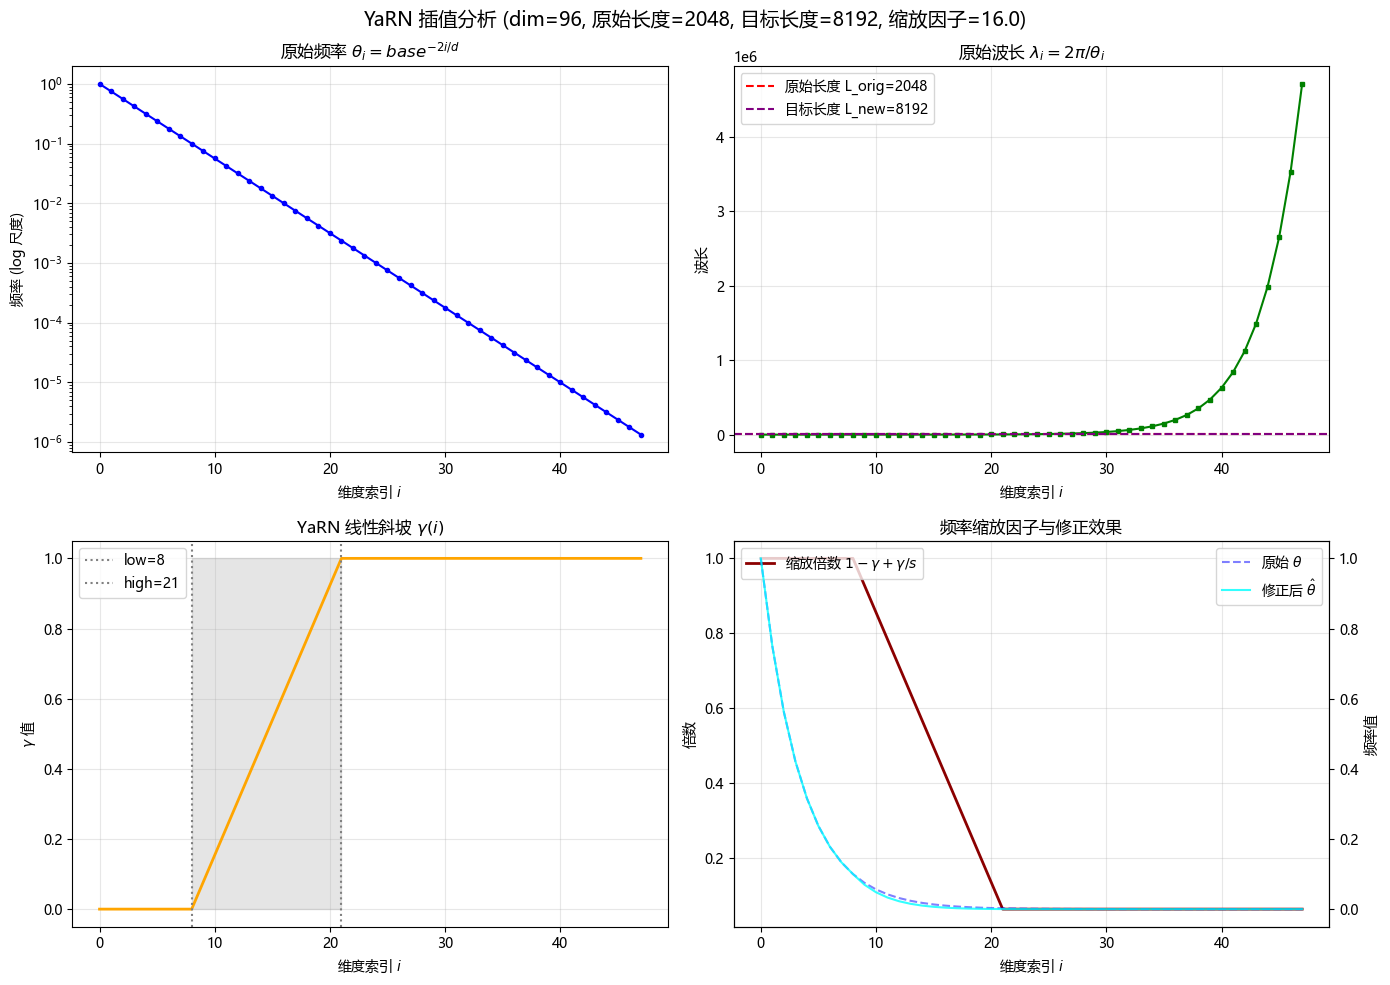

低频插值起始索引 (low)  : 8
高频外推结束索引 (high) : 21
斜坡有效区间宽度        : 14


In [18]:
# ---------- 参数配置 ----------
dim = 96          # head_dim，必须为偶数
rope_base = 1e6
orig_max = 2048    # 原始预训练长度
end = 8192         # 目标扩展长度（大于 orig_max 才会触发插值）
factor = 16.0      # 缩放因子 s
beta_fast = 32.0
beta_slow = 1.0

# ---------- 1. 计算基础频率 ----------
# i 的取值范围：0 到 dim//2 - 1
i_indices = torch.arange(0, dim // 2)
theta_i = 1.0 / (rope_base ** (2 * i_indices.float() / dim))  # 等价于 base^(-2i/d)

# ---------- 2. 计算 YaRN 线性斜坡 gamma(i) ----------
# 定义 inv_dim 函数
def inv_dim(b):
    # 注意：这里的 log 是自然对数，与代码中 math.log 一致
    return (dim * math.log(orig_max / (b * 2 * math.pi))) / (2 * math.log(rope_base))

low = max(math.floor(inv_dim(beta_fast)), 0)
high = min(math.ceil(inv_dim(beta_slow)), dim // 2 - 1)

# 计算 ramp (gamma)
ramp = torch.clamp((i_indices.float() - low) / max(high - low, 0.001), 0, 1)

# ---------- 3. 计算缩放后的频率 ----------
# 如果 end / orig_max <= 1.0，则 gamma 全为0，此处我们强制激活以展示效果
scale_factor = 1 - ramp + ramp / factor
theta_scaled = theta_i * scale_factor

# ---------- 4. 计算波长 ----------
wavelength_orig = 2 * math.pi / (theta_i + 1e-9)  # 加极小值防止除零
wavelength_scaled = 2 * math.pi / (theta_scaled + 1e-9)

# ---------- 5. 绘图 ----------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'YaRN 插值分析 (dim={dim}, 原始长度={orig_max}, 目标长度={end}, 缩放因子={factor})', fontsize=14)

# 子图 1: 原始频率 (对数坐标)
axs[0, 0].plot(i_indices.numpy(), theta_i.numpy(), color='blue', marker='o', markersize=3)
axs[0, 0].set_yscale('log')
axs[0, 0].set_title('原始频率 $\\theta_i = base^{-2i/d}$')
axs[0, 0].set_xlabel('维度索引 $i$')
axs[0, 0].set_ylabel('频率 (log 尺度)')
axs[0, 0].grid(True, alpha=0.3)

# 子图 2: 原始波长 (线性坐标)
axs[0, 1].plot(i_indices.numpy(), wavelength_orig.numpy(), color='green', marker='s', markersize=3)
axs[0, 1].axhline(y=orig_max, color='red', linestyle='--', label=f'原始长度 L_orig={orig_max}')
axs[0, 1].axhline(y=end, color='purple', linestyle='--', label=f'目标长度 L_new={end}')
axs[0, 1].set_title('原始波长 $\\lambda_i = 2\\pi / \\theta_i$')
axs[0, 1].set_xlabel('维度索引 $i$')
axs[0, 1].set_ylabel('波长')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 子图 3: YaRN 斜坡 gamma(i)
axs[1, 0].plot(i_indices.numpy(), ramp.numpy(), color='orange', linewidth=2)
axs[1, 0].axvline(x=low, color='gray', linestyle=':', label=f'low={low}')
axs[1, 0].axvline(x=high, color='gray', linestyle=':', label=f'high={high}')
axs[1, 0].fill_between(i_indices.numpy(), 0, 1, where=(i_indices >= low) & (i_indices <= high), alpha=0.2, color='gray')
axs[1, 0].set_title('YaRN 线性斜坡 $\\gamma(i)$')
axs[1, 0].set_xlabel('维度索引 $i$')
axs[1, 0].set_ylabel('$\\gamma$ 值')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 子图 4: 缩放倍数以及修正后的频率对比
axs[1, 1].plot(i_indices.numpy(), scale_factor.numpy(), color='darkred', linewidth=2, label='缩放倍数 $1-\\gamma+\\gamma/s$')
axs[1, 1].set_title('频率缩放因子与修正效果')
axs[1, 1].set_xlabel('维度索引 $i$')
axs[1, 1].set_ylabel('倍数')
axs[1, 1].legend(loc='upper left')
axs[1, 1].grid(True, alpha=0.3)

# 在子图4上叠加修正前后的频率对比（双纵轴）
ax2 = axs[1, 1].twinx()
ax2.plot(i_indices.numpy(), theta_i.numpy(), color='blue', alpha=0.5, linestyle='--', label='原始 $\\theta$')
ax2.plot(i_indices.numpy(), theta_scaled.numpy(), color='cyan', alpha=0.8, linestyle='-', label='修正后 $\\hat{\\theta}$')
ax2.set_ylabel('频率值', color='black')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 打印关键临界索引
print(f"低频插值起始索引 (low)  : {low}")
print(f"高频外推结束索引 (high) : {high}")
print(f"斜坡有效区间宽度        : {high - low + 1}")